# BME688 Gasklassifikation -- Experiment-Framework

Baseline- und Vergleichs-Pipeline für die aus `bme688_to_ei.py` / der
Streamlit-App exportierten Feature-Vektoren. Ziel ist die Einschätzung,
wie gut sich die vier Klassen anhand der Gaswiderstands-Features trennen
lassen -- bevor ihr das Ganze in Edge Impulse für die
Embedded-Deployment-Pipeline weiterverwendet.

**Wichtigstes Prinzip in diesem Notebook:** Der Train/Test-Split erfolgt
immer auf Ebene ganzer Mess-Sessions, nie auf Ebene einzelner Zeilen/Vektoren.
Warum das entscheidend ist, steht in Abschnitt 3.

**Neu:** Das Notebook ist als universelles Experimentier-Framework
aufgebaut. Eine zentrale Konfigurationszelle (Abschnitt 2) und eine
gemeinsame `evaluate_model()`-Funktion (Abschnitt 5) sorgen dafür, dass
sich neue Modelle (SVM, KNN, MLP, ...) mit minimalem Aufwand ergänzen und
alle Ergebnisse automatisch vergleichbar in `experiment_results.csv`
protokolliert werden. Details zur Architektur stehen im separaten
Dokument `notebook_dokumentation.md`.

## 1. Daten laden

Ladet hier eine mit `--combine label` oder `--combine all` (ohne
`--apply-split`, also `apply_split=False`) erzeugte CSV -- die enthält
mehrere Zeilen (= Vektoren) mit den Spalten `vector_id`, `label`, `session`,
`category` (hier noch `"unsplit"`), `n_imputed` und den Feature-Spalten.

Falls ihr mehrere Label-Dateien habt (eine je Klasse), einfach alle laden
und konkatenieren.

In [1]:
import sys
from pathlib import Path

# core.py muss im selben Ordner liegen (oder in sys.path aufgenommen werden)
app_path = "/home/tun/Projects/tuc/ML/FP-ML-repo/transformation_app"
if app_path not in sys.path:
    sys.path.append(app_path)

#lokale Module
import core
from core import train_test_split_by_session

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import (
    classification_report,
    ConfusionMatrixDisplay,
    confusion_matrix,
    accuracy_score,
    precision_recall_fscore_support,
)
from sklearn.model_selection import StratifiedGroupKFold


DATA_DIR = Path("/home/tun/Projects/tuc/ML/Forschungspraktikum/CSV/transformiert/Badset/level2_per_profile/")  # ggf. anpassen

# Alle CSVs in diesem Ordner einlesen und zusammenführen
csv_files = list(DATA_DIR.glob("*.csv"))
assert csv_files, f"Keine CSVs in {DATA_DIR} gefunden -- Pfad anpassen."
df = pd.concat([pd.read_csv(f) for f in csv_files], ignore_index=True)

meta_cols = ["vector_id", "label", "session", "category", "n_imputed",
             "sensor_index", "heater_profile_id", "cycle_id"]
feature_cols = [c for c in df.columns if c not in meta_cols]

print(df.shape)
print("Klassen:", df["label"].unique())
print("Sessions je Klasse:\n", df.groupby("label")["session"].nunique())
df.head()

(907, 28)
Klassen: <StringArray>
['Rasur', 'Zähne putzen', 'Raumspray', 'Deospray']
Length: 4, dtype: str
Sessions je Klasse:
 label
Deospray        2
Rasur           5
Raumspray       3
Zähne putzen    5
Name: session, dtype: int64


,vector_id,label,session,category,heater_profile_id,cycle_id_a,cycle_id_b,n_imputed,sA_gasres_step0,sB_gasres_step0,...,sA_gasres_step5,sB_gasres_step5,sA_gasres_step6,sB_gasres_step6,sA_gasres_step7,sB_gasres_step7,sA_gasres_step8,sB_gasres_step8,sA_gasres_step9,sB_gasres_step9
0,BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Ra...,Rasur,BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Rasur,unsplit,heater_322,0,0,0,5.984994,6.001274,...,5.133390,5.159409,4.355315,4.359954,4.904041,4.950056,5.073987,5.100744,5.165699,5.179711
1,BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Ra...,Rasur,BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Rasur,unsplit,heater_322,1,1,0,6.856104,6.804487,...,5.578133,5.514340,4.880224,4.888019,5.193396,5.208348,5.259792,5.265851,5.308559,5.304180
2,BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Ra...,Rasur,BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Rasur,unsplit,heater_322,2,2,0,7.051856,6.947600,...,5.659471,5.576210,4.972714,4.952330,5.293546,5.292047,5.346693,5.334705,5.374716,5.363700
3,BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Ra...,Rasur,BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Rasur,unsplit,heater_322,3,3,0,7.156849,7.054552,...,5.690465,5.594576,5.009086,4.989276,5.338572,5.327884,5.382934,5.369918,5.405318,5.388190
4,BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Ra...,Rasur,BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Rasur,unsplit,heater_322,4,4,0,7.215725,7.108825,...,5.703768,5.605723,5.022812,4.999068,5.362233,5.346693,5.404349,5.384165,5.423825,5.402095


## 2. Experiment-Konfiguration

Alle Einstellungen, die ein Experiment eindeutig beschreiben, stehen ab
jetzt an **einer** Stelle. Wenn ihr ein neues Experiment fahren wollt
(anderes Feature-Level, andere Imputation, Skalierung an/aus, ...), ändert
ihr nur diese Zelle und führt das Notebook erneut aus -- der Rest passt
sich automatisch an.

- `FEATURE_LEVEL` / `FEATURE_SET`: welche Rohdaten bzw. welche konkreten
  Merkmale verwendet wurden (z. B. `"mean,std"`, `"all_features"`, `"PCA20"`).
- `IMPUTATION`: wie fehlende Werte behandelt wurden.
- `SCALING`: ob `StandardScaler` angewendet wird. Für Random Forest
  praktisch irrelevant, für SVM/KNN/MLP/Logistische Regression aber wichtig.
- `EXPERIMENT_NOTES`: Freitext für Besonderheiten (z. B. "MQ-2 entfernt",
  "nur Küche", "Ausreißer entfernt", "Balanced Dataset").
- `RESULT_FILE` / `RESULTS_DIR`: wohin die CSV-Zeile bzw. die
  Zusatzausgaben (Confusion Matrix, Feature Importance, Report) je
  Experiment geschrieben werden.

In [2]:
# ====================================================
# Experiment-Konfiguration -- hier und nur hier anpassen
# ====================================================

FEATURE_LEVEL = "Statistical Features"   # z. B. "Level 1", "Level 2", "Statistical Features"
FEATURE_SET = "all_features"             # welche konkreten Spalten/Features verwendet wurden
IMPUTATION = "Median"                    # wie n_imputed-Werte behandelt wurden
SCALING = True                           # StandardScaler an/aus

TEST_RATIO = 0.25
SEED = 7

EXPERIMENT_NOTES = ""                    # Freitext, z. B. "Ausreißer entfernt"

RESULT_FILE = Path("experiment_results.csv")
RESULTS_DIR = Path("results")            # results/<Experiment-ID>/ mit Plots & Report je Lauf
RESULTS_DIR.mkdir(exist_ok=True)

## 3. Warum session-basiert splitten?

Innerhalb einer Mess-Session sind aufeinanderfolgende Zyklen stark
korreliert (gleiche Umgebungsbedingungen, gleiche Sensordrift, gleiches
Rauschmuster). Ein zufälliger Split auf Zeilenebene würde Zeilen derselben
Session sowohl im Training als auch im Test landen lassen -- das Modell
"erkennt" dann teilweise nur die Session wieder, nicht das eigentliche
Gasereignis. Ergebnis: die Testgenauigkeit sieht deutlich besser aus, als
das Modell auf echten, neuen Messungen tatsächlich leisten würde
(Data Leakage).

**Regel:** Eine Session gehört immer komplett entweder zu Training ODER
zu Test, nie zu beiden. Das übernimmt `train_test_split_by_session` aus
`core.py` automatisch -- dieselbe Funktion, die auch in der Streamlit-App
und der CLI genutzt wird.

In [3]:
df_split = train_test_split_by_session(
    df, test_ratio=TEST_RATIO, seed=SEED,   # aus der Experiment-Konfiguration oben
)

# Sanity-Check: keine Session in beiden Kategorien, Verhältnis je Klasse plausibel
check = df_split.groupby(["label", "category"])["session"].nunique().unstack(fill_value=0)
print(check)

overlap = (set(df_split.loc[df_split.category == "training", "session"]) &
           set(df_split.loc[df_split.category == "testing", "session"]))
assert not overlap, f"Leakage! Sessions in beiden Kategorien: {overlap}"
print("OK, keine Session in Training UND Test.")

train_df = df_split[df_split.category == "training"]
test_df  = df_split[df_split.category == "testing"]
print(f"Training: {len(train_df)} Vektoren aus {train_df.session.nunique()} Sessions")
print(f"Test:     {len(test_df)} Vektoren aus {test_df.session.nunique()} Sessions")

category      testing  training
label                          
Deospray            1         1
Rasur               1         4
Raumspray           1         2
Zähne putzen        1         4
OK, keine Session in Training UND Test.
Training: 643 Vektoren aus 11 Sessions
Test:     257 Vektoren aus 4 Sessions


## 4. Features (optional) skalieren

Der `StandardScaler` wird **nur auf den Trainingsdaten gefittet** und dann
auf Test angewendet -- sonst fließt Information aus dem Test in die
Skalierung ein (ebenfalls eine Form von Leakage, auch wenn subtiler als
der Session-Fehler oben).

Ob skaliert wird, hängt jetzt vom Flag `SCALING` aus der
Experiment-Konfiguration ab:

| Modell | Skalierung nötig? |
|---|---|
| Random Forest | praktisch irrelevant |
| SVM | sehr wichtig |
| KNN | sehr wichtig |
| Logistische Regression | wichtig |
| MLP | wichtig |

Setzt `SCALING = False` und führt das Notebook erneut aus, um denselben
Code ohne Skalierung laufen zu lassen (z. B. um den Effekt für den Random
Forest zu prüfen).

In [4]:
X_train = train_df[feature_cols].values
y_train = train_df["label"].values
X_test  = test_df[feature_cols].values
y_test  = test_df["label"].values

if SCALING:
    scaler = StandardScaler().fit(X_train)
    X_train_model = scaler.transform(X_train)
    X_test_model  = scaler.transform(X_test)
else:
    X_train_model = X_train
    X_test_model  = X_test

## 5. Universelle Evaluierungsfunktion

`evaluate_model()` ist die zentrale Stelle, über die ab jetzt **jedes**
Modell läuft -- Random Forest, SVM, KNN, MLP oder was auch immer ihr
später ergänzt. Sie übernimmt automatisch:

- Training und Vorhersage (inkl. Zeitmessung)
- Berechnung von Accuracy, Precision, Recall, F1 (gewichtet) und der
  False-Positive-Rate (nur bei binärer Klassifikation sinnvoll definiert)
- Confusion Matrix und `classification_report`
- Speichern einer Confusion-Matrix-Heatmap und -- falls das Modell
  `feature_importances_` unterstützt -- eines Feature-Importance-Diagramms
  unter `results/<Experiment-ID>/`
- Anhängen einer Ergebniszeile an `experiment_results.csv`

Für neue Modelle braucht ihr also **nur noch** das Modellobjekt
auszutauschen (siehe Abschnitt 7) -- der Rest bleibt identisch.

Jedes Experiment bekommt automatisch eine **Experiment-ID** in der Form
`YYYYMMDD_HHMMSS_<Modellname>`. Damit lässt sich jede CSV-Zeile auch
Monate später eindeutig den zugehörigen Plots und dem Report zuordnen.

In [5]:
import json
import time
from datetime import datetime


def evaluate_model(
    model,
    X_train,
    X_test,
    y_train,
    y_test,
    train_df,
    test_df,
):
    """
    Trainiert ein beliebiges sklearn-kompatibles Modell, berechnet
    Kennzahlen, speichert Confusion Matrix (+ ggf. Feature Importance)
    unter results/<Experiment-ID>/ und haengt eine Zeile an
    RESULT_FILE an.

    Rueckgabe: dict mit y_pred, confusion_matrix, classification_report
    und allen berechneten Kennzahlen.
    """

    experiment_id = f"{datetime.now():%Y%m%d_%H%M%S}_{model.__class__.__name__}"
    exp_dir = RESULTS_DIR / experiment_id
    exp_dir.mkdir(parents=True, exist_ok=True)

    t0 = time.perf_counter()
    model.fit(X_train, y_train)
    train_time = time.perf_counter() - t0

    t0 = time.perf_counter()
    y_pred = model.predict(X_test)
    predict_time = time.perf_counter() - t0

    accuracy = accuracy_score(y_test, y_pred)
    precision, recall, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, average="weighted", zero_division=0,
    )

    labels_sorted = sorted(np.unique(y_test))
    cm = confusion_matrix(y_test, y_pred, labels=labels_sorted)

    if len(labels_sorted) == 2:
        tn, fp, fn, tp = cm.ravel()
        fpr = fp / (fp + tn)
    else:
        fpr = np.nan

    report_text = classification_report(y_test, y_pred, zero_division=0)
    with open(exp_dir / "report.txt", "w") as f:
        f.write(report_text)

    # Confusion Matrix als Heatmap speichern
    fig, ax = plt.subplots(figsize=(6, 6))
    sns.heatmap(
        cm, annot=True, fmt="d", cmap="Blues",
        xticklabels=labels_sorted, yticklabels=labels_sorted, ax=ax,
    )
    ax.set_xlabel("Vorhergesagt")
    ax.set_ylabel("Tatsaechlich")
    ax.set_title(f"Confusion Matrix -- {model.__class__.__name__}")
    plt.tight_layout()
    fig.savefig(exp_dir / "confusion_matrix.png", dpi=150)
    plt.show()

    # Feature Importance speichern, falls das Modell das unterstuetzt
    if hasattr(model, "feature_importances_"):
        importances = pd.Series(model.feature_importances_, index=feature_cols)
        importances = importances.sort_values(ascending=False).head(20)

        fig, ax = plt.subplots(figsize=(8, 6))
        importances.iloc[::-1].plot.barh(ax=ax)
        ax.set_xlabel("Feature Importance")
        ax.set_title(f"Top Features -- {model.__class__.__name__}")
        plt.tight_layout()
        fig.savefig(exp_dir / "feature_importance.png", dpi=150)
        plt.show()

    result = {
        "Timestamp": pd.Timestamp.now(),
        "Experiment ID": experiment_id,
        "Model": model.__class__.__name__,
        "Parameters": json.dumps(model.get_params()),
        "Feature Level": FEATURE_LEVEL,
        "Feature Set": FEATURE_SET,
        "Imputation": IMPUTATION,
        "Scaling": SCALING,
        "Test Ratio": TEST_RATIO,
        "Seed": SEED,
        "Train Vectors": len(X_train),
        "Test Vectors": len(X_test),
        "Train Sessions": train_df["session"].nunique(),
        "Test Sessions": test_df["session"].nunique(),
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1": f1,
        "False Positive Rate": fpr,
        "Training Time": train_time,
        "Prediction Time": predict_time,
        "Notes": EXPERIMENT_NOTES,
    }

    result_df = pd.DataFrame([result])
    if RESULT_FILE.exists():
        old = pd.read_csv(RESULT_FILE)
        result_df = pd.concat([old, result_df], ignore_index=True)
    result_df.to_csv(RESULT_FILE, index=False)

    print(f"Experiment-ID: {experiment_id}  (Ausgaben in {exp_dir})")
    print(report_text)

    return {
        "experiment_id": experiment_id,
        "y_pred": y_pred,
        "confusion_matrix": cm,
        "classification_report": report_text,
        "metrics": result,
    }

## 6. Baseline-Modell: Random Forest

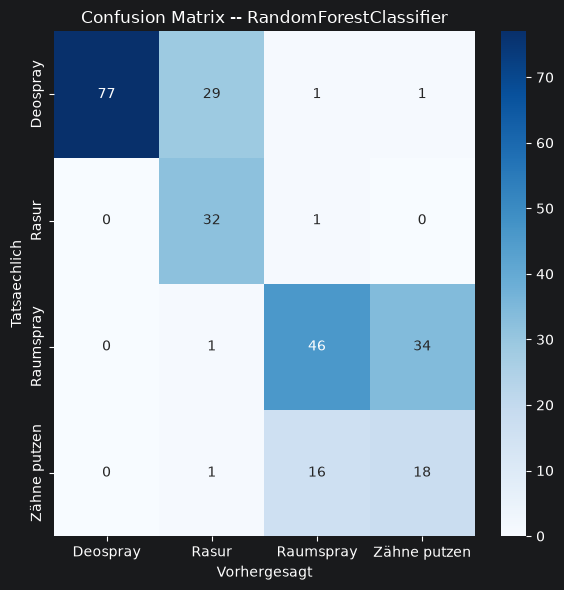

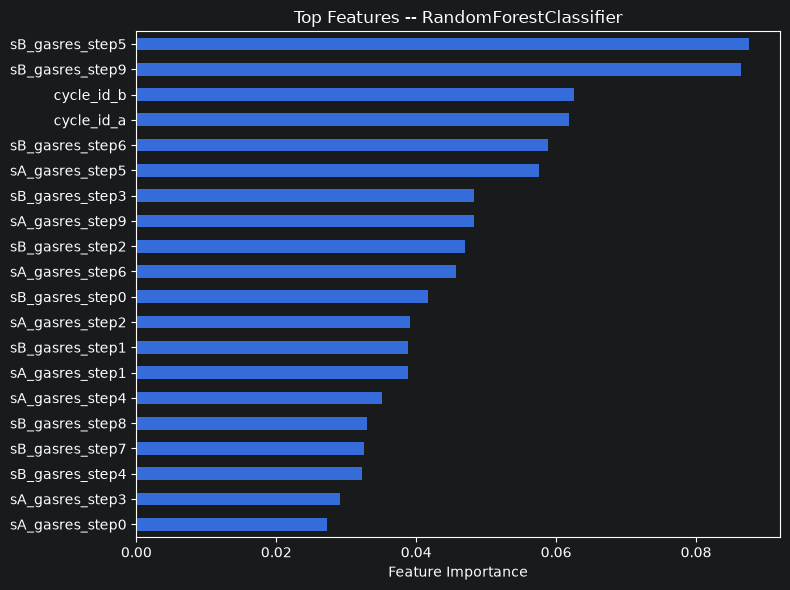

Experiment-ID: 20260731_115348_RandomForestClassifier  (Ausgaben in results/20260731_115348_RandomForestClassifier)
              precision    recall  f1-score   support

    Deospray       1.00      0.71      0.83       108
       Rasur       0.51      0.97      0.67        33
   Raumspray       0.72      0.57      0.63        81
Zähne putzen       0.34      0.51      0.41        35

    accuracy                           0.67       257
   macro avg       0.64      0.69      0.64       257
weighted avg       0.76      0.67      0.69       257



In [6]:
rf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1,
)

rf_result = evaluate_model(
    rf, X_train_model, X_test_model, y_train, y_test, train_df, test_df,
)

## 7. Weitere Modelle vergleichen

Ab hier reicht jeweils nur noch ein Modellobjekt plus der Aufruf von
`evaluate_model()` -- Training, Auswertung, Plots und CSV-Export laufen
automatisch identisch zum Random Forest oben ab. Denkt bei linearen bzw.
distanzbasierten Modellen (SVM, KNN, MLP) daran, `SCALING = True` in der
Konfigurationszelle (Abschnitt 2) gesetzt zu haben.

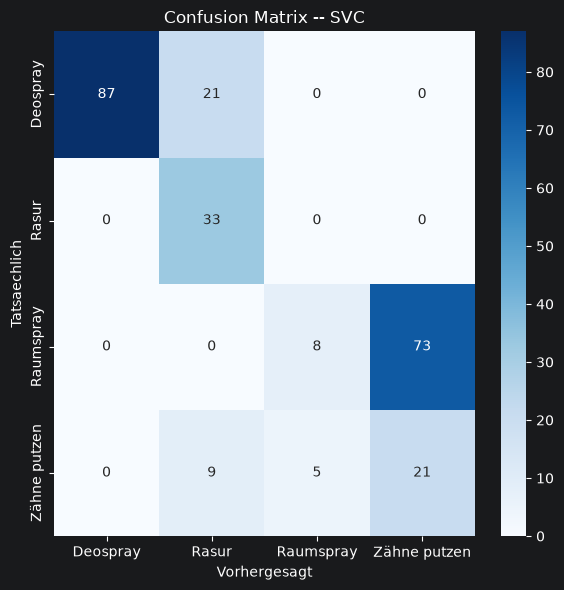

Experiment-ID: 20260731_115352_SVC  (Ausgaben in results/20260731_115352_SVC)
              precision    recall  f1-score   support

    Deospray       1.00      0.81      0.89       108
       Rasur       0.52      1.00      0.69        33
   Raumspray       0.62      0.10      0.17        81
Zähne putzen       0.22      0.60      0.33        35

    accuracy                           0.58       257
   macro avg       0.59      0.63      0.52       257
weighted avg       0.71      0.58      0.56       257



In [7]:
svm = SVC(
    C=1,
    kernel="rbf",
)

svm_result = evaluate_model(
    svm, X_train_model, X_test_model, y_train, y_test, train_df, test_df,
)

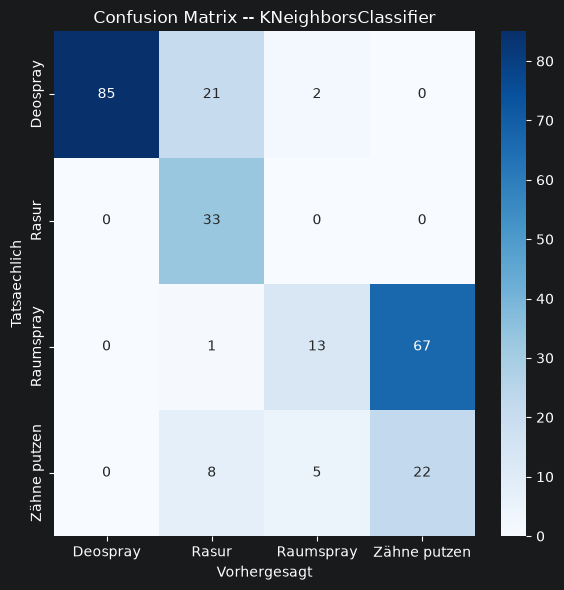

Experiment-ID: 20260731_115353_KNeighborsClassifier  (Ausgaben in results/20260731_115353_KNeighborsClassifier)
              precision    recall  f1-score   support

    Deospray       1.00      0.79      0.88       108
       Rasur       0.52      1.00      0.69        33
   Raumspray       0.65      0.16      0.26        81
Zähne putzen       0.25      0.63      0.35        35

    accuracy                           0.60       257
   macro avg       0.61      0.64      0.55       257
weighted avg       0.73      0.60      0.59       257



In [8]:
knn = KNeighborsClassifier(
    n_neighbors=5,
)

knn_result = evaluate_model(
    knn, X_train_model, X_test_model, y_train, y_test, train_df, test_df,
)

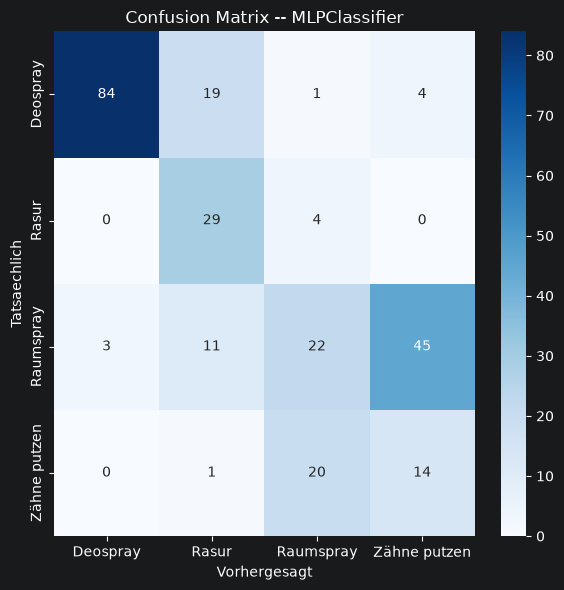

Experiment-ID: 20260731_115354_MLPClassifier  (Ausgaben in results/20260731_115354_MLPClassifier)
              precision    recall  f1-score   support

    Deospray       0.97      0.78      0.86       108
       Rasur       0.48      0.88      0.62        33
   Raumspray       0.47      0.27      0.34        81
Zähne putzen       0.22      0.40      0.29        35

    accuracy                           0.58       257
   macro avg       0.53      0.58      0.53       257
weighted avg       0.65      0.58      0.59       257



In [9]:
mlp = MLPClassifier(
    hidden_layer_sizes=(64, 32),
    max_iter=1000,
    random_state=42,
)

mlp_result = evaluate_model(
    mlp, X_train_model, X_test_model, y_train, y_test, train_df, test_df,
)

## 8. Robustere Schätzung: Cross-Validation über Sessions

Ein einzelner Split ist bei wenigen Sessions je Klasse ziemlich
"zufallsabhängig" -- je nachdem, welche Session zufällig im Test landet,
schwankt die Genauigkeit stark. `StratifiedGroupKFold` macht dasselbe wie
oben (Gruppierung nach Session, keine Session in mehreren Folds), aber über
mehrere Folds hinweg gemittelt -- das gibt ein deutlich stabileres Bild als
ein einzelner Split, gerade bei noch überschaubarer Session-Anzahl.

Auch hier wird die `SCALING`-Einstellung aus der Konfiguration respektiert.

In [10]:
X = df[feature_cols].values
y = df["label"].values
groups = df["session"].values

n_splits = min(5, df.groupby("label")["session"].nunique().min())
sgkf = StratifiedGroupKFold(n_splits=n_splits, shuffle=True, random_state=SEED)

scores = []
for fold, (train_idx, test_idx) in enumerate(sgkf.split(X, y, groups)):
    if SCALING:
        scaler_cv = StandardScaler().fit(X[train_idx])
        X_tr_cv = scaler_cv.transform(X[train_idx])
        X_te_cv = scaler_cv.transform(X[test_idx])
    else:
        X_tr_cv = X[train_idx]
        X_te_cv = X[test_idx]

    clf_cv = RandomForestClassifier(
        n_estimators=300, class_weight="balanced", random_state=42, n_jobs=-1
    )
    clf_cv.fit(X_tr_cv, y[train_idx])
    acc = clf_cv.score(X_te_cv, y[test_idx])
    scores.append(acc)
    print(f"Fold {fold}: Accuracy = {acc:.3f}  "
          f"(Test-Sessions: {sorted(set(groups[test_idx]))})")

print(f"\nMittlere Accuracy: {np.mean(scores):.3f} +/- {np.std(scores):.3f}")

Fold 0: Accuracy = 0.604  (Test-Sessions: ['BME688_2026-06-08_15-21-04_nzz7v8xkp0bd5qmp_Deospray', 'BME688_2026-06-19_07-38-04_mufpzvgtzjv57lym_Rasur', 'BME688_2026-06-25_05-46-09_8g93jctwzpndtn46_Rasur', 'BME688_2026-07-16_06-44-28_d83wxekfauj1deow_Zähne_putzen', 'BME688_2026-07-19_14-56-07_312joss43wbvgnyj_Raumspray', 'BME688_2026-07-19_15-47-04_j3dbznv72xblkbrj_Raumspray', 'BME688_2026-07-19_18-14-12_h65kuvlb8c7c72qt_Zähne_putzen'])
Fold 1: Accuracy = 0.701  (Test-Sessions: ['BME688_2026-06-08_08-43-51_bmjwvwb4jh52qf5v_Rasur', 'BME688_2026-06-08_12-09-49_gtxhsq429d6t7qkt_Deospray', 'BME688_2026-06-22_06-30-00_fo6gb2iih6ksbvbm_Rasur', 'BME688_2026-06-28_17-05-20_mpkj4wexte0077bm_Rasur', 'BME688_2026-07-15_06-02-20_3lpikz6jqpn9fyxm_Zähne_putzen', 'BME688_2026-07-16_21-00-32_7vs92nosv775dsi8_Zähne_putzen', 'BME688_2026-07-19_23-10-29_u1i9bhwgsl09ll64_Zähne_putzen', 'BME688_2026-07-20_15-29-19_elliogpuyyxdfayw_Raumspray'])

Mittlere Accuracy: 0.653 +/- 0.049


## 9. Modellvergleich

Jede Ausführung von `evaluate_model()` hat eine Zeile in
`experiment_results.csv` erzeugt. Hier laden wir die komplette
Experiment-Historie und sortieren nach F1-Score -- so seht ihr auf einen
Blick, welches Experiment bisher am besten abgeschnitten hat.

In [11]:
results = pd.read_csv(RESULT_FILE)
results.sort_values("F1", ascending=False)[
    ["Experiment ID", "Model", "Feature Level", "Feature Set", "Scaling",
     "Accuracy", "Precision", "Recall", "F1", "False Positive Rate", "Notes"]
]

,Experiment ID,Model,Feature Level,Feature Set,Scaling,Accuracy,Precision,Recall,F1,False Positive Rate,Notes
0,20260731_115348_RandomForestClassifier,RandomForestClassifier,Statistical Features,all_features,True,0.673152,0.758239,0.673152,0.691105,NaN,NaN
3,20260731_115354_MLPClassifier,MLPClassifier,Statistical Features,all_features,True,0.579767,0.645597,0.579767,0.589380,NaN,NaN
2,20260731_115353_KNeighborsClassifier,KNeighborsClassifier,Statistical Features,all_features,True,0.595331,0.726021,0.595331,0.587891,NaN,NaN
1,20260731_115352_SVC,SVC,Statistical Features,all_features,True,0.579767,0.711872,0.579767,0.561242,NaN,NaN


## 10. Nächste Schritte

- Modelle für **Level 2/3** (Sensorpaar bzw. alle Sensoren kombiniert)
  genauso durchspielen und vergleichen, ob die zusätzliche Information die
  Genauigkeit rechtfertigt -- gegen mehr Rechenaufwand/Overfitting-Risiko
  bei kleinen Datensätzen abwägen.
- Hyperparameter-Suche (`GridSearchCV` / `RandomizedSearchCV`) mit
  `StratifiedGroupKFold` als Splitter ergänzen, statt Parameter von Hand
  zu setzen.
- Vorverarbeitung + Modell als `sklearn.pipeline.Pipeline` bündeln, damit
  Skalierung und Modell immer zusammen persistiert/deployt werden.
- Für die finale Embedded-Deployment-Pipeline: Datensatz (mit demselben
  session-sauberen Split!) in Edge Impulse hochladen und dort einen
  Klassifikator im Impulse Designer trainieren/quantisieren -- dieses
  Notebook dient primär der schnellen Voreinschätzung, dem Modellvergleich
  und der Feature-Analyse.

Eine ausführliche Erklärung der Architektur, aller Spalten in
`experiment_results.csv` sowie Hinweise zur Erweiterung findet ihr in
`notebook_dokumentation.md`.